# 2 · Has the Value Premium Broken Down?

Replicating 1993 is table stakes. The live question — the one practitioners actually argue about — is whether the **value premium survived the 2010s**. Growth, led by US tech, trounced value for the best part of a decade, and HML spent years near zero or negative. Three stories compete: the premium was *arbitraged away*; book value became a *worse signal* as intangibles grew; or *cheap money* structurally favoured long-duration growth stocks. We split the sample and test each era.

> **Data note.** Results below reflect the bundled cache (through its vintage date, printed by the setup cell). The `Value comeback (2022–present)` period only populates once you refresh with `dl.load_all(download=True)`; with the offline cache it is shown as N/A rather than guessed.

In [1]:
import sys; sys.path.insert(0, "../src")
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import data_loader as dl, analysis as an

pd.set_option("display.float_format", lambda v: f"{v:,.3f}")
plt.rcParams.update({"figure.dpi": 120, "axes.spines.top": False,
                     "axes.spines.right": False, "axes.grid": True,
                     "grid.color": "#e9ebef"})
NAVY, TEAL, RUST, GREY = "#1f2a44", "#2a9d8f", "#c1463c", "#8a8f99"

# download=False uses the bundled cache; set True to refresh from Ken French.
factors, ports = dl.load_all(download=False)
VINTAGE = f"{factors.index.max():%b %Y}"
print(f"{len(factors)} months  {factors.index.min():%Y-%m} .. {factors.index.max():%Y-%m}")


682 months  1963-07 .. 2020-04


In [2]:
PERIODS = {
    "Original (1963-1991)":          ("1963-07", "1991-12"),
    "Lost decade (2010-2021)":       ("2010-01", "2021-12"),
    "Value comeback (2022-present)": ("2022-01", None),
}

## The value premium, era by era
Annualised premium and a Newey-West $t$-stat for each factor.

In [3]:
prem = an.premia_by_period(factors, PERIODS)
prem.pivot(index="period", columns="factor", values="ann_%").reindex(PERIODS).round(2)

factor,HML,Mkt-RF,SMB
period,,,
Original (1963-1991),5.060,4.990,2.660
Lost decade (2010-2021),-4.870,12.590,-1.490
Value comeback (2022-present),NaN,NaN,NaN


In [4]:
hml = prem[prem.factor == "HML"].set_index("period").reindex(PERIODS)
hml[["ann_%", "t_NW", "n"]].round(2)

,ann_%,t_NW,n
period,,,
Original (1963-1991),5.060,2.540,342
Lost decade (2010-2021),-4.870,-1.520,124
Value comeback (2022-present),NaN,NaN,0


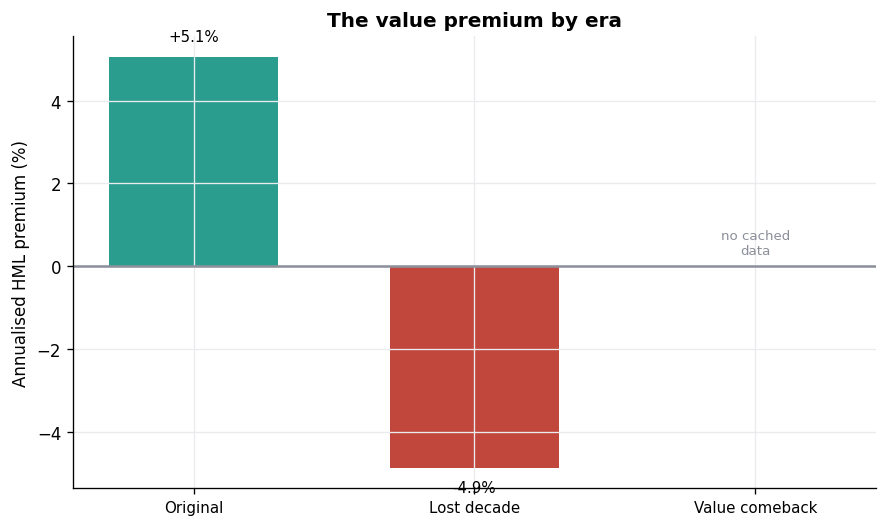

In [5]:
vals = hml["ann_%"].values
fig, ax = plt.subplots(figsize=(7.5, 4.5))
colors = [TEAL if (not np.isnan(v) and v >= 0) else RUST for v in vals]
ax.bar(range(len(vals)), np.nan_to_num(vals), color=colors, width=0.6)
for i, v in enumerate(vals):
    if np.isnan(v):
        ax.text(i, 0.3, "no cached\ndata", ha="center", color=GREY, fontsize=8)
    else:
        ax.text(i, v + np.sign(v)*0.3, f"{v:+.1f}%", ha="center",
                va="bottom" if v >= 0 else "top", fontsize=9)
ax.axhline(0, color=GREY); ax.set_xticks(range(len(vals)))
ax.set_xticklabels([p.split(" (")[0] for p in PERIODS], fontsize=9)
ax.set_ylabel("Annualised HML premium (%)")
ax.set_title("The value premium by era", weight="bold"); plt.tight_layout()

The original sample shows the textbook positive, significant premium. In the 2010s it is **negative** — value didn't merely weaken, it cost you, even as the market returned double digits a year.

## When exactly did it fade?
A 60-month rolling premium dates the rollover. HML rode high through the 1980s–2000s, then slid below zero in the 2010s. SMB (size) is shown for contrast — noisier, and also soft late in the sample.

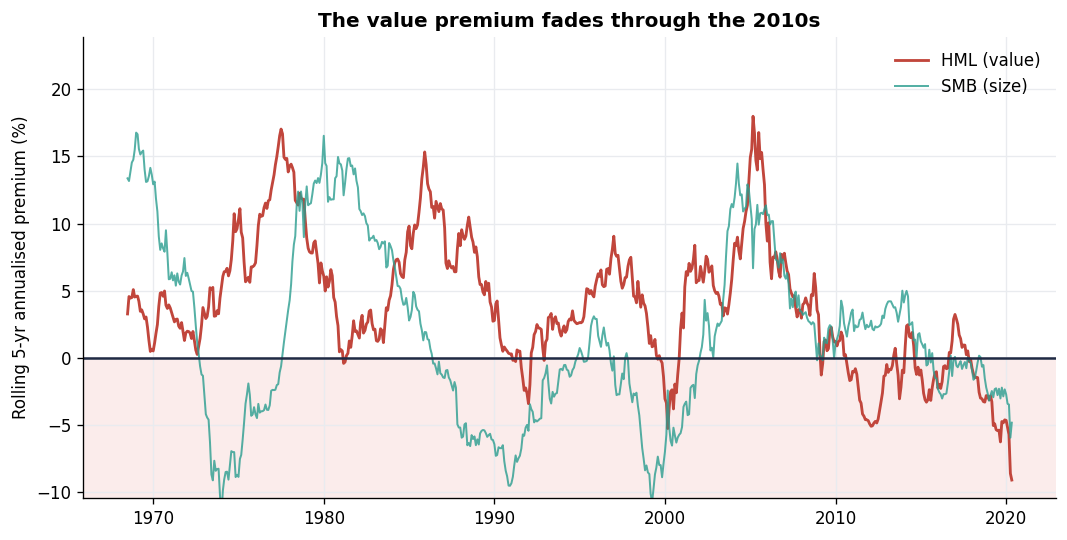

In [6]:
roll_hml = an.rolling_premium(factors["HML"], 60)
roll_smb = an.rolling_premium(factors["SMB"], 60)
fig, ax = plt.subplots(figsize=(9, 4.6))
ax.axhspan(-100, 0, color="#fbeceb")
ax.plot(roll_hml.index, roll_hml, color=RUST, lw=1.7, label="HML (value)")
ax.plot(roll_smb.index, roll_smb, color=TEAL, lw=1.2, alpha=.8, label="SMB (size)")
ax.axhline(0, color=NAVY); ax.set_ylim(roll_hml.min()*1.15, None)
ax.set_ylabel("Rolling 5-yr annualised premium (%)")
ax.set_title("The value premium fades through the 2010s", weight="bold")
ax.legend(frameon=False); plt.tight_layout()

## Loading vs premium — a crucial distinction
Run FF3 on the small-value portfolio separately in each era. Its HML **loading** barely moves (~0.55): it is just as much a *value* portfolio as ever. What changed is the **premium** paid for that exposure. The factor didn't stop existing — it stopped paying.

In [7]:
by = an.ff3_by_period(ports["SMALL HiBM"], factors, PERIODS)
by[["n", "h_HML", "t_HML", "alpha_%mo", "R2"]].round(3)

,n,h_HML,t_HML,alpha_%mo,R2
period,,,,,
Original (1963-1991),342,0.550,18.409,0.116,0.960
Lost decade (2010-2021),124,0.574,12.829,0.181,0.960
Value comeback (2022-present),0,NaN,NaN,NaN,NaN


## Did size hold up better than value?
Comparing annualised volatilities and Sharpe ratios of a value-tilted vs growth-tilted basket across eras.

In [8]:
value, growth = an.value_growth_legs(ports)
rows = []
for label, (s, e) in PERIODS.items():
    v, g = value.loc[s:e], growth.loc[s:e]
    rf = factors["RF"].loc[s:e]
    rows.append({"period": label, "value_Sharpe": an.sharpe(v, rf),
                 "growth_Sharpe": an.sharpe(g, rf)})
pd.DataFrame(rows).set_index("period").round(2)

,value_Sharpe,growth_Sharpe
period,,
Original (1963-1991),0.550,0.220
Lost decade (2010-2021),0.340,0.710
Value comeback (2022-present),NaN,NaN


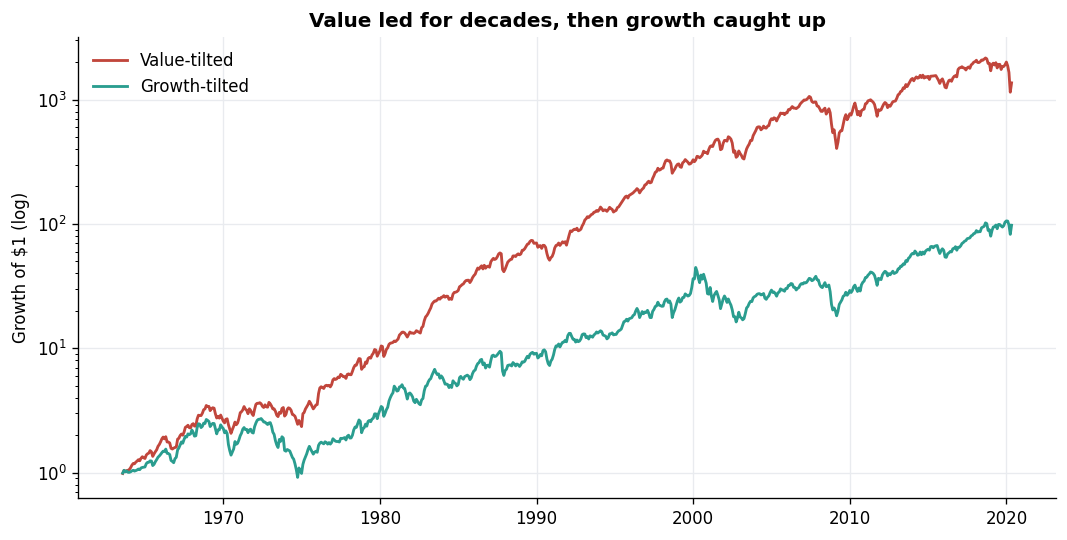

In [9]:
vc, gc = (1+value).cumprod(), (1+growth).cumprod()
fig, ax = plt.subplots(figsize=(9, 4.6))
ax.plot(vc.index, vc, color=RUST, lw=1.7, label="Value-tilted")
ax.plot(gc.index, gc, color=TEAL, lw=1.7, label="Growth-tilted")
ax.set_yscale("log"); ax.set_ylabel("Growth of $1 (log)")
ax.set_title("Value led for decades, then growth caught up", weight="bold")
ax.legend(frameon=False); plt.tight_layout()

## Reading the evidence: risk or behaviour?

Fama & French read the premium as **rational risk compensation** — value firms are distressed and procyclical, so investors demand a higher expected return. The **behavioural** camp (Lakonishok–Shleifer–Vishny, Shiller) reads it as **mispricing** — investors overpay for glamour and underpay for boring, and the premium is the correction.

What does the era-by-era pattern favour? The drawdown lines up tightly with the **2010–2021 zero-rate regime** and the re-rating of long-duration growth, and the small-value portfolio's *loading* never changed — only the *payoff* did. That is awkward for a pure risk story (the riskiness of value firms didn't obviously fall), and more consistent with a structural/behavioural account where the price of the exposure swung with the macro and sentiment backdrop. It is **not** clean evidence that the premium is gone for good: a factor whose payoff is regime-dependent is exactly what you'd expect to recover when the regime turns — which is the hypothesis the `download=True` extension into 2022+ is built to test.

### Where the model breaks
FF3 still can't price **momentum**, and book value is a fraying signal in an intangibles-heavy economy — a software firm's most valuable asset never touches its balance sheet, so a low book-to-market may now flag a capital-light compounder rather than an overpriced one. Both are live reasons the *measured* value factor can misbehave without the underlying idea being wrong.

*Re-run this notebook with* `dl.load_all(download=True)` *to extend every table and chart through the present, including the post-2022 value rebound.*